# Artificial Neural Network Assignment
## Case Study: Sonar Mine vs Rock Classification

In this assignment, an Artificial Neural Network model is developed to classify sonar signals as either a Mine or a Rock.  
The dataset contains sonar signal readings collected from underwater objects. Each record has 60 numerical input features and one target class label.

The main objective of this assignment is to perform data preprocessing, build an ANN model, tune its hyperparameters, and evaluate its performance using suitable classification metrics.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Importing the  Required Libraries#

In [2]:
!pip install tensorflow
!pip install keras

In [3]:
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt

# For preprocessing and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# For ANN model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Loading the dataset

df = pd.read_csv("/content/drive/MyDrive/ASSIGNMENTS/Neural Network/sonardataset.csv", header=None)

# Display first five rows
df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


In [5]:
# Checking the shape of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 209
Number of columns: 61


 The dataset contains 208 rows and 61 columns. Out of these, the first 60 columns are numerical input features and the last column is the target variable.bold text

In [6]:
# Assigning meaningful column names

feature_columns = [f"Feature_{i}" for i in range(1, 61)]
df.columns = feature_columns + ["Target"]

# Display first few rows after assigning column names
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59,Feature_60,Target
0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
1,0.02,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.018,0.0084,0.009,0.0032,R
2,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.014,0.0049,0.0052,0.0044,R
3,0.0262,0.0582,0.1099,0.1083,0.0974,0.228,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.018,0.0244,0.0316,0.0164,0.0095,0.0078,R
4,0.01,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.015,0.0085,0.0073,0.005,0.0044,0.004,0.0117,R


In [7]:
# Checking basic information of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 61 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Feature_1   209 non-null    object
 1   Feature_2   209 non-null    object
 2   Feature_3   209 non-null    object
 3   Feature_4   209 non-null    object
 4   Feature_5   209 non-null    object
 5   Feature_6   209 non-null    object
 6   Feature_7   209 non-null    object
 7   Feature_8   209 non-null    object
 8   Feature_9   209 non-null    object
 9   Feature_10  209 non-null    object
 10  Feature_11  209 non-null    object
 11  Feature_12  209 non-null    object
 12  Feature_13  209 non-null    object
 13  Feature_14  209 non-null    object
 14  Feature_15  209 non-null    object
 15  Feature_16  209 non-null    object
 16  Feature_17  209 non-null    object
 17  Feature_18  209 non-null    object
 18  Feature_19  209 non-null    object
 19  Feature_20  209 non-null    object
 20  Feature_21

In [8]:
# Statistical summary of numerical features

df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_52,Feature_53,Feature_54,Feature_55,Feature_56,Feature_57,Feature_58,Feature_59,Feature_60,Target
count,209,209,209,209,209,209,209,209,209,209,...,209,209,209,209,209,209,209,209,209,209
unique,178,183,191,182,194,197,196,202,206,208,...,145,135,135,130,123,122,125,120,110,3
top,0.0201,0.0523,0.0623,0.0608,0.0647,0.069,0.0771,0.1833,0.0598,0.2354,...,0.0091,0.0129,0.0079,0.0036,0.0054,0.0037,0.0036,0.007,0.0053,M
freq,5,2,2,3,2,2,3,2,2,2,...,5,5,5,5,5,7,6,6,7,111


The statistical summary shows the count, mean, standard deviation, minimum and maximum values of all numerical features. Since all input values are numerical sonar signal readings, they can be directly used for model training after scaling.

In [9]:
# Checking missing values in the dataset

missing_values = df.isnull().sum()

print("Total missing values in dataset:", missing_values.sum())
missing_values

Total missing values in dataset: 0


,0
Feature_1,0
Feature_2,0
Feature_3,0
Feature_4,0
Feature_5,0
...,...
Feature_57,0
Feature_58,0
Feature_59,0
Feature_60,0


There are no missing values in the dataset. Therefore, no missing value treatment is required.

In [10]:
# Checking target classes before cleaning

print("Unique target values before filtering:")
print(df["Target"].unique())

print("\nClass distribution before filtering:")
print(df["Target"].value_counts())

Unique target values before filtering:
['Y' 'R' 'M']

Class distribution before filtering:
Target
M    111
R     97
Y      1
Name: count, dtype: int64


# **Remove Invalid Target Class**

In [11]:
# Filtering only valid Sonar classes: M and R

df_filtered = df[df["Target"].isin(["M", "R"])].copy()

print("Shape before filtering:", df.shape)
print("Shape after filtering:", df_filtered.shape)

print("\nClass distribution after filtering:")
print(df_filtered["Target"].value_counts())

Shape before filtering: (209, 61)
Shape after filtering: (208, 61)

Class distribution after filtering:
Target
M    111
R     97
Name: count, dtype: int64


The Sonar dataset should contain only two target classes: M for Mine and R for Rock. During preprocessing, one invalid target value was found. Since this value was not part of the actual problem statement, it was removed before model training. After filtering, only M and R classes were kept.

# ** Visualizing target class distribution**

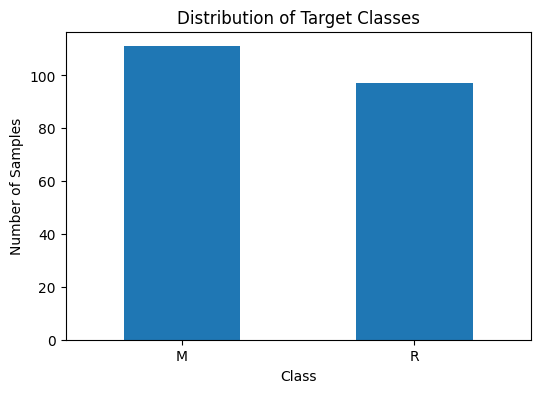

In [12]:

df_filtered["Target"].value_counts().plot(kind="bar", figsize=(6, 4))

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

The target variable contains two classes:
- M represents Mine
- R represents Rock

The dataset is almost balanced, as both classes have nearly similar numbers of samples.

# **Separate Features and Targe**

In [13]:
# Separating input features and target variable

X = df_filtered.drop("Target", axis=1)
y = df_filtered["Target"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (208, 60)
Shape of y: (208,)


# **Encode Target Variable**

In [14]:
# Encoding target labels

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded values:", np.unique(y_encoded))

Classes: ['M' 'R']
Encoded values: [0 1]


The target variable is categorical, so it is converted into numerical format using Label Encoding.  
The classes Mine and Rock are encoded as 0 and 1.

# **Train-Test Split**

In [15]:
# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training data shape: (166, 60)
Testing data shape: (42, 60)

Training class distribution:
0    89
1    77
Name: count, dtype: int64

Testing class distribution:
0    22
1    20
Name: count, dtype: int64


# **Feature Scaling**

In [16]:
# Feature scaling using StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


# **Build ANN Model**

In [17]:
# Building ANN model

default_model = Sequential()

# Input layer + first hidden layer
default_model.add(Dense(32, activation="relu", input_shape=(60,)))

# Second hidden layer
default_model.add(Dense(16, activation="relu"))

# Output layer
default_model.add(Dense(1, activation="sigmoid"))

# Compile the model
default_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Model summary
default_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

# **Train ANN Model**

In [18]:
# Training  ANN model

history_default = default_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 371ms/step - accuracy: 0.3788 - loss: 1.0086 - val_accuracy: 0.4118 - val_loss: 0.8077
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4848 - loss: 0.8211 - val_accuracy: 0.5000 - val_loss: 0.7685
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5682 - loss: 0.7107 - val_accuracy: 0.5000 - val_loss: 0.7174
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6439 - loss: 0.6390 - val_accuracy: 0.5294 - val_loss: 0.6825
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6894 - loss: 0.5857 - val_accuracy: 0.5588 - val_loss: 0.6523
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7348 - loss: 0.5437 - val_accuracy: 0.5882 - val_loss: 0.6224
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7727 - loss: 0.5079 - val_accuracy: 0.5882 - val_loss: 0.6020
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8106 - loss: 0.4769 - val_accuracy: 0.6765 - val_loss

# **Plot Model Accuracy**

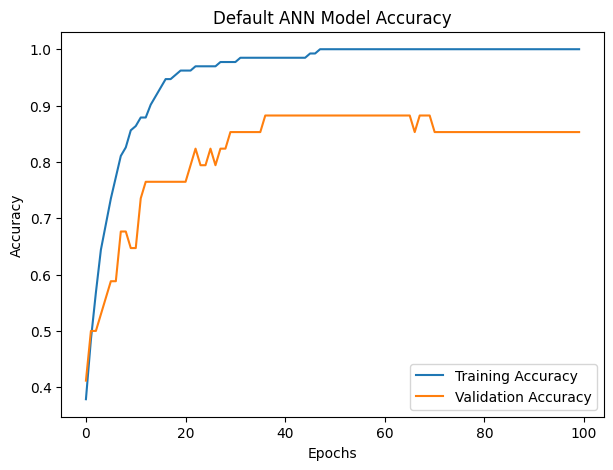

In [19]:
# Plotting training and validation accuracy

plt.figure(figsize=(7, 5))
plt.plot(history_default.history["accuracy"], label="Training Accuracy")
plt.plot(history_default.history["val_accuracy"], label="Validation Accuracy")

plt.title("Default ANN Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# **Plot  Model Loss**

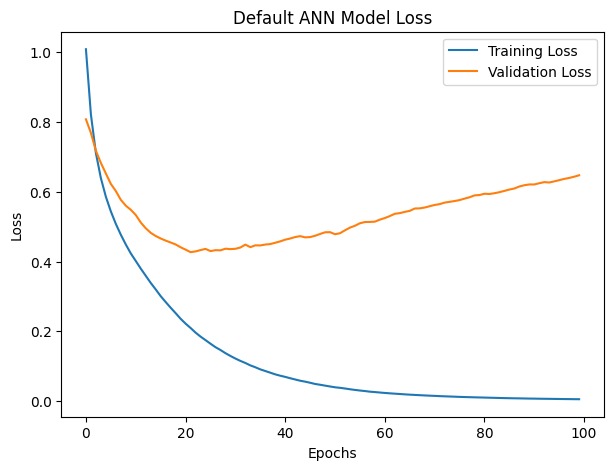

In [20]:
# Plotting training and validation loss

plt.figure(figsize=(7, 5))
plt.plot(history_default.history["loss"], label="Training Loss")
plt.plot(history_default.history["val_loss"], label="Validation Loss")

plt.title("Default ANN Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **Predict Using  Model**

In [21]:
# Making predictions using  model

y_pred_default_prob = default_model.predict(X_test_scaled)

# Converting probabilities into class labels
y_pred_default = (y_pred_default_prob > 0.5).astype(int).ravel()

print("First 10 predictions:", y_pred_default[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step
First 10 predictions: [1 1 1 0 0 0 0 1 0 1]


# **Evaluate ANN Model**

In [22]:
# Evaluating ANN model

default_accuracy = accuracy_score(y_test, y_pred_default)
default_precision = precision_score(y_test, y_pred_default)
default_recall = recall_score(y_test, y_pred_default)
default_f1 = f1_score(y_test, y_pred_default)

print("Default ANN Model Performance")
print("Accuracy:", round(default_accuracy, 4))
print("Precision:", round(default_precision, 4))
print("Recall:", round(default_recall, 4))
print("F1 Score:", round(default_f1, 4))

Default ANN Model Performance
Accuracy: 0.9286
Precision: 0.9474
Recall: 0.9
F1 Score: 0.9231


# **Classification Report for  Model**

In [23]:
# Classification report for model

print("Classification Report - Default ANN Model")
print(classification_report(y_test, y_pred_default, target_names=label_encoder.classes_))

Classification Report - Default ANN Model
              precision    recall  f1-score   support

           M       0.91      0.95      0.93        22
           R       0.95      0.90      0.92        20

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



# **Confusion Matrix for Model**

In [24]:

# Confusion matrix

cm_default = confusion_matrix(y_test, y_pred_default)

print("Confusion Matrix - Default ANN Model")
print(cm_default)

Confusion Matrix - Default ANN Model
[[21  1]
 [ 2 18]]


# **Hyperparameter Tuning**

In [25]:

# Function to create ANN model with different hyperparameters

def create_ann_model(hidden_layers=1, neurons=32, activation="relu", learning_rate=0.001):
    model = Sequential()

    # First hidden layer
    model.add(Dense(neurons, activation=activation, input_shape=(60,)))

    # Additional hidden layers
    for i in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))

    # Output layer
    model.add(Dense(1, activation="sigmoid"))

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [26]:

# Defining  Hyperparameter values for tuning

hidden_layers_list = [1, 2]
neurons_list = [16, 32, 64]
activation_list = ["relu", "tanh"]
learning_rate_list = [0.001, 0.01]

results = []

** Grid Search**

In [27]:
#  grid search for hyperparameter tuning

for hidden_layers in hidden_layers_list:
    for neurons in neurons_list:
        for activation in activation_list:
            for learning_rate in learning_rate_list:

                print("Training model with:",
                      "Hidden Layers =", hidden_layers,
                      "| Neurons =", neurons,
                      "| Activation =", activation,
                      "| Learning Rate =", learning_rate)

                model = create_ann_model(
                    hidden_layers=hidden_layers,
                    neurons=neurons,
                    activation=activation,
                    learning_rate=learning_rate
                )

                history = model.fit(
                    X_train_scaled,
                    y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.20,
                    verbose=0
                )

                y_pred_prob = model.predict(X_test_scaled, verbose=0)
                y_pred = (y_pred_prob > 0.5).astype(int).ravel()

                acc = accuracy_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred)
                rec = recall_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)

                results.append({
                    "Hidden Layers": hidden_layers,
                    "Neurons": neurons,
                    "Activation": activation,
                    "Learning Rate": learning_rate,
                    "Accuracy": acc,
                    "Precision": prec,
                    "Recall": rec,
                    "F1 Score": f1
                })

Training model with: Hidden Layers = 1 | Neurons = 16 | Activation = relu | Learning Rate = 0.001
Training model with: Hidden Layers = 1 | Neurons = 16 | Activation = relu | Learning Rate = 0.01


Training model with: Hidden Layers = 1 | Neurons = 16 | Activation = tanh | Learning Rate = 0.001
Training model with: Hidden Layers = 1 | Neurons = 16 | Activation = tanh | Learning Rate = 0.01
Training model with: Hidden Layers = 1 | Neurons = 32 | Activation = relu | Learning Rate = 0.001
Training model with: Hidden Layers = 1 | Neurons = 32 | Activation = relu | Learning Rate = 0.01
Training model with: Hidden Layers = 1 | Neurons = 32 | Activation = tanh | Learning Rate = 0.001
Training model with: Hidden Layers = 1 | Neurons = 32 | Activation = tanh | Learning Rate = 0.01
Training model with: Hidden Layers = 1 | Neurons = 64 | Activation = relu | Learning Rate = 0.001
Training model with: Hidden Layers = 1 | Neurons = 64 | Activation = relu | Learning Rate = 0.01
Training model with: Hidden Layers = 1 | Neurons = 64 | Activation = tanh | Learning Rate = 0.001
Training model with: Hidden Layers = 1 | Neurons = 64 | Activation = tanh | Learning Rate = 0.01
Training model with: Hidd

**Showing Tuning Results**

In [28]:
# Converting tuning results into DataFrame

results_df = pd.DataFrame(results)

# Sorting based on accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Hidden Layers,Neurons,Activation,Learning Rate,Accuracy,Precision,Recall,F1 Score
2,1,16,tanh,0.001,0.904762,0.944444,0.85,0.894737
20,2,64,relu,0.001,0.880952,0.941176,0.80,0.864865
23,2,64,tanh,0.010,0.880952,0.941176,0.80,0.864865
14,2,16,tanh,0.001,0.857143,0.937500,0.75,0.833333
12,2,16,relu,0.001,0.857143,0.937500,0.75,0.833333
16,2,32,relu,0.001,0.857143,0.937500,0.75,0.833333
1,1,16,relu,0.010,0.833333,0.882353,0.75,0.810811
0,1,16,relu,0.001,0.833333,0.933333,0.70,0.800000
15,2,16,tanh,0.010,0.833333,0.933333,0.70,0.800000
13,2,16,relu,0.010,0.833333,0.882353,0.75,0.810811


In [29]:
# Selecting best hyperparameters

best_params = results_df.iloc[0]

print("Best Hyperparameters:")
print(best_params)

Best Hyperparameters:
Hidden Layers           1
Neurons                16
Activation           tanh
Learning Rate       0.001
Accuracy         0.904762
Precision        0.944444
Recall               0.85
F1 Score         0.894737
Name: 2, dtype: object


# **Tuned ANN Model**

In [30]:
# Building tuned ANN model using best hyperparameters

tuned_model = create_ann_model(
    hidden_layers=int(best_params["Hidden Layers"]),
    neurons=int(best_params["Neurons"]),
    activation=best_params["Activation"],
    learning_rate=float(best_params["Learning Rate"])
)

# Model summary
tuned_model.summary()

# Training tuned model
history_tuned = tuned_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 16)             │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.5000 - loss: 0.8179 - val_accuracy: 0.6765 - val_loss: 0.7312
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5758 - loss: 0.7204 - val_accuracy: 0.6765 - val_loss: 0.6620
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6212 - loss: 0.6499 - val_accuracy: 0.7059 - val_loss: 0.6109
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6667 - loss: 0.6006 - val_accuracy: 0.7941 - val_loss: 0.5675
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7273 - loss: 0.5603 - val_accuracy: 0.7941 - val_loss: 0.5350
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7576 - loss: 0.5263 - val_accuracy: 0.7941 - val_loss: 0.5150
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7727 - loss: 0.4996 - val_accuracy: 0.7941 - val_loss: 0.4899
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7879 - loss: 0.4752 - val_accuracy: 0.7941 - val_loss

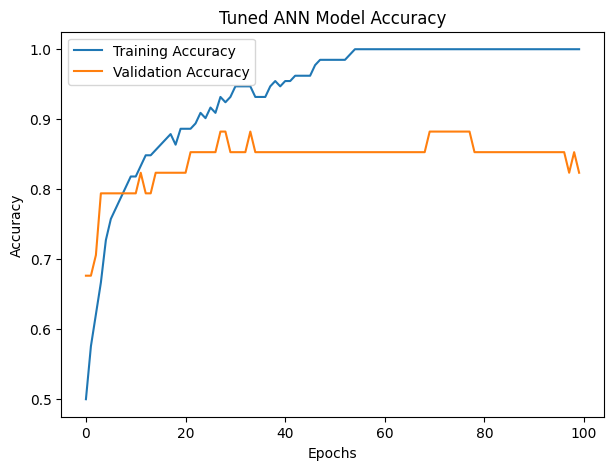

In [31]:
# Plotting tuned model accuracy

plt.figure(figsize=(7, 5))
plt.plot(history_tuned.history["accuracy"], label="Training Accuracy")
plt.plot(history_tuned.history["val_accuracy"], label="Validation Accuracy")

plt.title("Tuned ANN Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

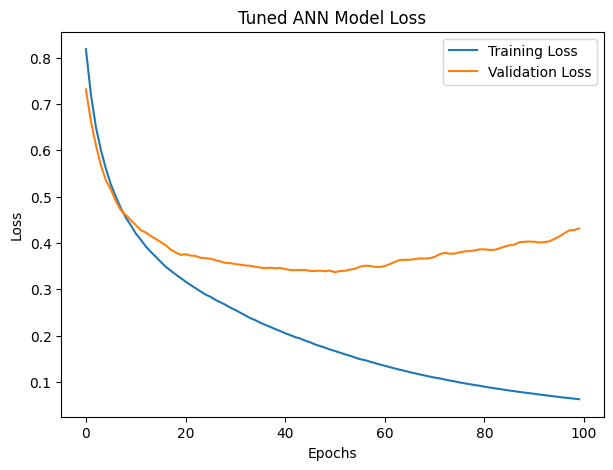

In [32]:

# Plotting tuned model loss

plt.figure(figsize=(7, 5))
plt.plot(history_tuned.history["loss"], label="Training Loss")
plt.plot(history_tuned.history["val_loss"], label="Validation Loss")

plt.title("Tuned ANN Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [33]:
# Making predictions using tuned model

y_pred_tuned_prob = tuned_model.predict(X_test_scaled)

# Converting probabilities into class labels
y_pred_tuned = (y_pred_tuned_prob > 0.5).astype(int).ravel()

print("First 10 tuned predictions:", y_pred_tuned[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
First 10 tuned predictions: [1 1 0 0 0 0 0 1 0 1]


In [34]:
# Evaluating tuned ANN model

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned ANN Model Performance")
print("Accuracy:", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall:", round(tuned_recall, 4))
print("F1 Score:", round(tuned_f1, 4))

Tuned ANN Model Performance
Accuracy: 0.8333
Precision: 0.9333
Recall: 0.7
F1 Score: 0.8


In [35]:
# Classification report for tuned model

print("Classification Report - Tuned ANN Model")
print(classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_))

Classification Report - Tuned ANN Model
              precision    recall  f1-score   support

           M       0.78      0.95      0.86        22
           R       0.93      0.70      0.80        20

    accuracy                           0.83        42
   macro avg       0.86      0.83      0.83        42
weighted avg       0.85      0.83      0.83        42



In [36]:

# Confusion matrix for tuned model

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Confusion Matrix - Tuned ANN Model")
print(cm_tuned)

Confusion Matrix - Tuned ANN Model
[[21  1]
 [ 6 14]]


# **Model Comparison**

In [37]:
# Default model prediction and evaluation

y_pred_default_prob = default_model.predict(X_test_scaled)
y_pred_default = (y_pred_default_prob > 0.5).astype(int).ravel()

default_accuracy = accuracy_score(y_test, y_pred_default)
default_precision = precision_score(y_test, y_pred_default)
default_recall = recall_score(y_test, y_pred_default)
default_f1 = f1_score(y_test, y_pred_default)

print("Default ANN Model Performance")
print("Accuracy:", round(default_accuracy, 4))
print("Precision:", round(default_precision, 4))
print("Recall:", round(default_recall, 4))
print("F1 Score:", round(default_f1, 4))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Default ANN Model Performance
Accuracy: 0.9286
Precision: 0.9474
Recall: 0.9
F1 Score: 0.9231


In [38]:
# Tuned model prediction and evaluation

y_pred_tuned_prob = tuned_model.predict(X_test_scaled)
y_pred_tuned = (y_pred_tuned_prob > 0.5).astype(int).ravel()

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned ANN Model Performance")
print("Accuracy:", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall:", round(tuned_recall, 4))
print("F1 Score:", round(tuned_f1, 4))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Tuned ANN Model Performance
Accuracy: 0.8333
Precision: 0.9333
Recall: 0.7
F1 Score: 0.8


Compare Default and Tuned Model

In [39]:
comparison_df = pd.DataFrame({
    "Model": ["Default ANN", "Tuned ANN"],
    "Accuracy": [default_accuracy, tuned_accuracy],
    "Precision": [default_precision, tuned_precision],
    "Recall": [default_recall, tuned_recall],
    "F1 Score": [default_f1, tuned_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Default ANN,0.928571,0.947368,0.9,0.923077
1,Tuned ANN,0.833333,0.933333,0.7,0.800000


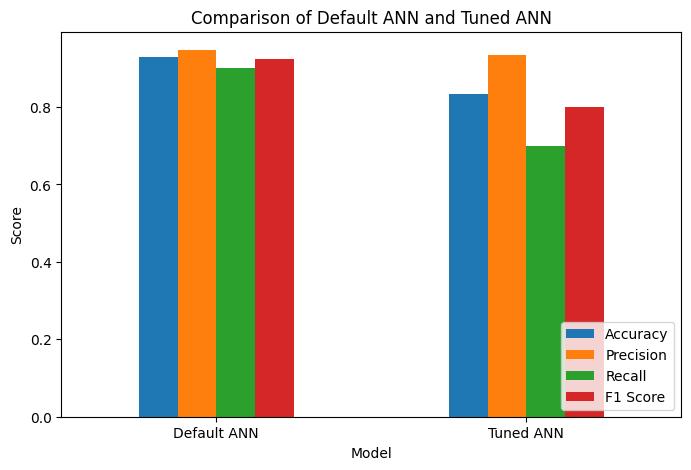

In [40]:
# Visual comparison of default and tuned model performance

comparison_df.set_index("Model").plot(kind="bar", figsize=(8, 5))

plt.title("Comparison of Default ANN and Tuned ANN")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

## **Data Exploration and Preprocessing Explanation**



The Sonar dataset was loaded using Pandas. The dataset originally contains sonar signal values and a target class. The first 60 columns represent numerical sonar signal features and the last column represents the target class.

The target column was checked before model training. The actual Sonar dataset should contain only two classes: M for Mine and R for Rock. During preprocessing, one invalid target value was found. Since this value was not part of the given problem statement, it was removed from the dataset. After cleaning, only M and R classes were used.

Missing values were also checked and no major missing value issue was found. The target variable was encoded into numerical format using LabelEncoder. Feature scaling was performed using StandardScaler because neural networks perform better when input features are on a similar scale.

# **Model Implementation Explanation**



A basic Artificial Neural Network model was implemented using TensorFlow and Keras. The model was created using the Sequential API.

The default ANN model contained:
- One input layer with 60 input features
- Two hidden layers using ReLU activation
- One output layer using Sigmoid activation

Since this is a binary classification problem, binary crossentropy was used as the loss function. Adam optimizer was used for model training. The dataset was divided into training and testing sets using an 80:20 ratio.

# **Hyperparameter Tuning Explanation**



Hyperparameter tuning was performed using a manual grid search approach. Different combinations of hidden layers, neurons, activation functions and learning rates were tested.

The following hyperparameters were tuned:
- Number of hidden layers
- Number of neurons
- Activation function
- Learning rate

Each model was trained and evaluated on the test set. The model with the highest accuracy was selected as the tuned ANN model.

# **Evaluation Explanation**

The performance of both the default ANN model and the tuned ANN model was evaluated using accuracy, precision, recall and F1-score. Classification report and confusion matrix were also used to understand the model performance in more detail.

Accuracy shows the overall correctness of the model. Precision shows how many predicted positive cases were actually correct. Recall shows how many actual positive cases were correctly identified. F1-score gives a balanced measure of precision and recall.

The tuned model was compared with the default model to observe the effect of hyperparameter tuning.

# **Final Conclusion**

In this assignment, an Artificial Neural Network was developed to classify Sonar signals into Mine and Rock classes. The dataset was first explored and preprocessed. Invalid target values were removed, the target variable was encoded, and input features were scaled.

A default ANN model was trained using TensorFlow/Keras. After that, hyperparameter tuning was performed by testing different combinations of hidden layers, neurons, activation functions and learning rates.

The results show that ANN can be used effectively for binary classification problems like Sonar Mine vs Rock detection. Hyperparameter tuning helps in improving or stabilizing model performance. Since the dataset is small, a moderately complex ANN model is more suitable than a very deep model.